## Outline
This Notebook will look at the EDA aspect with deleting unnecessary rows and performing some kind of cleaning along the way.

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('C:\\Users\\Wajih\\Work (DataScience)\\CAPSTONE PROJECTS\\Real Estate Project\\Zameen.com\\Data Cleaning\\zameen_cleaned_new_v2.csv',index_col=0)

In [7]:
df.head()

,Real Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,...,Kitchens,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
0,D-12/2,House,12.00,7,10.0,6,D-12,10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...",...,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
1,D-12/1,House,5.20,4,4.4,3,D-12,4.44 Marla Single Unit Luxury corner House wit...,"Built in year, Parking Spaces: 3, Double Glaze...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...",...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2,D-12/4,House,4.30,5,4.4,3,D-12,4.44 Marla Single Unit Luxury House with Open ...,"Built in year, Parking Spaces: 1, Double Glaze...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
3,D-12/1,House,5.75,6,5.0,5,D-12,5 Marla Double Unit Front-Open 50 ft street Ho...,"Built in year: 4, Parking Spaces: 2, Double Gl...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 1...",...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
4,Bahria Enclave - Sector H,House,2.70,4,5.0,3,Bahria Town,Brand-New Designer House for Sale in Bahria En...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...",...,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN


In [8]:
df.columns

Index(['Real Location', 'Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)',
       'Bedroom(s)', 'Location', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'Main Location', 'Building',
       'IsPrimeLoc', 'SolarInstalled', 'WaterBore', 'CornerHouse',
       'luxury_type', 'Built in year', 'Parking Spaces', 'Floor',
       'Lobby in Building', 'Elevators', 'Service Elevators in Building',
       'Floor in Building', 'Bedrooms', 'Bathrooms', 'Servant Quarters',
       'Kitchens', 'Store Rooms', 'Swimming Pool', 'Sauna', 'Jacuzzi',
       'Security Staff', 'Maintenance Staff', 'Facilities for Disabled',
       'Laundry or Dry Cleaning Facility', 'Communal/Shared Kitchen'],
      dtype='str')

*Removing 'Location','Real Location' as we will not be needing it*

- Main Location --> Location of the Flats and Houses
- Building --> Only for Flats

In [9]:
df.drop(columns=['Real Location','Location'],inplace=True)

In [13]:
cols = ['Main Location'] + [c for c in df.columns if c != 'Main Location']
df = df[cols]
cols = ['Building'] + [c for c in df.columns if c != 'Building']
df = df[cols]

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 2677 entries, 0 to 2686
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Building                            646 non-null    str    
 1   Main Location                       2677 non-null   str    
 2   Type                                2677 non-null   str    
 3   Price(Cr)                           2677 non-null   float64
 4   Bath(s)                             2677 non-null   str    
 5   Area(Marla)                         2677 non-null   float64
 6   Bedroom(s)                          2677 non-null   str    
 7   Description                         2677 non-null   str    
 8   Amenities: Main Features            2546 non-null   str    
 9   Amenities: Rooms                    2471 non-null   str    
 10  Amenities: Healthcare Recreational  2174 non-null   str    
 11  Amenities: Other Facilities         2387 non-null   str    

Will remove :<br> *'Description', 'Amenities: Main Features', 'Amenities: Rooms',
       'Amenities: Other Facilities'* <br>but keeping them for now for better decisions

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 2677 entries, 0 to 2686
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Building                            646 non-null    str    
 1   Main Location                       2677 non-null   str    
 2   Type                                2677 non-null   str    
 3   Price(Cr)                           2677 non-null   float64
 4   Bath(s)                             2677 non-null   str    
 5   Area(Marla)                         2677 non-null   float64
 6   Bedroom(s)                          2677 non-null   str    
 7   Description                         2677 non-null   str    
 8   Amenities: Main Features            2546 non-null   str    
 9   Amenities: Rooms                    2471 non-null   str    
 10  Amenities: Healthcare Recreational  2174 non-null   str    
 11  Amenities: Other Facilities         2387 non-null   str    

In [17]:
df.duplicated().sum()

np.int64(1)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
# No of null values in each column
df.isnull().sum()

Building                              2030
Main Location                            0
Type                                     0
Price(Cr)                                0
Bath(s)                                  0
Area(Marla)                              0
Bedroom(s)                               0
Description                              0
Amenities: Main Features               131
Amenities: Rooms                       206
Amenities: Healthcare Recreational     503
Amenities: Other Facilities            289
IsPrimeLoc                               0
SolarInstalled                           0
WaterBore                                0
CornerHouse                              0
luxury_type                              0
Built in year                          438
Parking Spaces                         300
Floor                                  721
Lobby in Building                     2186
Elevators                             2217
Service Elevators in Building         2249
Floor in Bu

## Type

In [23]:
df['Type'].value_counts()

Type
House         1992
Flat           646
Farm House      35
Penthouse        3
Name: count, dtype: int64

In [24]:
sns.set_palette(["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"])

<Axes: xlabel='Type', ylabel='count'>

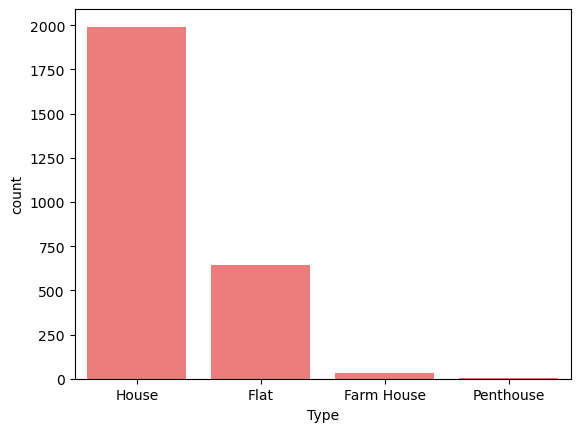

In [25]:
sns.countplot(x=df['Type'])

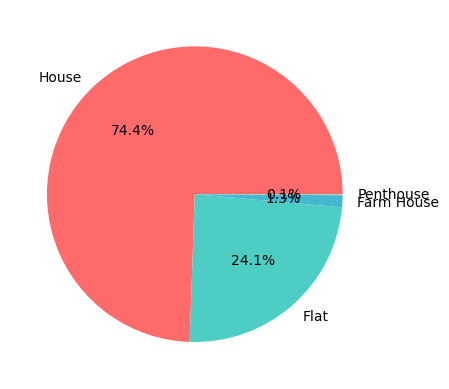

In [26]:
plt.pie(x=df['Type'].value_counts(),labels=df['Type'].value_counts().index,autopct='%1.1f%%');

### Observations
- In our Data, mostly data consists of House, then flats.
- Very few are PentHouse and Farm House

## Price(Cr)

In [27]:
df['Price(Cr)'].describe()

count     2676.000000
mean        35.920868
std       1353.107659
min          0.290000
25%          2.372500
50%          4.300000
75%         10.500000
max      70000.000000
Name: Price(Cr), dtype: float64

<Axes: xlabel='Price(Cr)', ylabel='Density'>

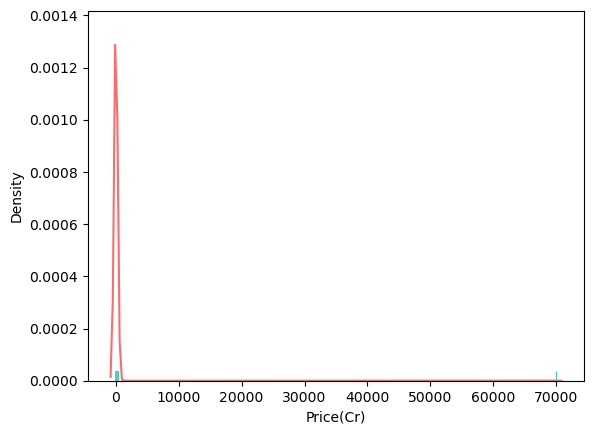

In [28]:
sns.kdeplot(df['Price(Cr)'])
sns.rugplot(df['Price(Cr)'])

In [29]:
df[df['Price(Cr)']==df['Price(Cr)'].max()]

,Building,Main Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,...,Kitchens,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
1207,NaN,Faisal Town Phase 1,House,70000.0,6,14.0,6,14 Marla Home For Sale In F-18 Faisal Town Isl...,NaN,"Bedrooms: 6, Bathrooms: 6, Servant Quarters: 1...",...,2.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN


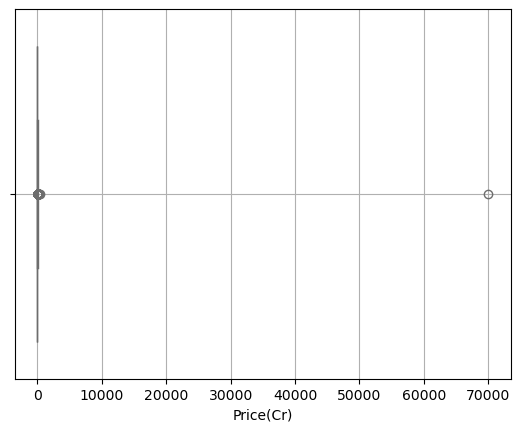

In [30]:
sns.boxplot(x=df['Price(Cr)'])
plt.grid();

In [35]:
# Removing the obvious outlier 
df = df[df['Price(Cr)']!=df['Price(Cr)'].max()]

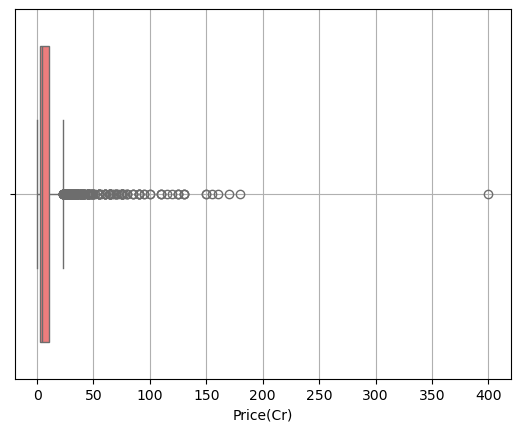

In [36]:
sns.boxplot(x=df['Price(Cr)'])
plt.grid();

### Descriptive Statistics
- No Null values
- Mean (11.37 Cr) is greater than Median (4.6 Cr)
- Standard Deviation is very high indicating high variability in data
### Visualiations
- Data is Right Skewed
- A lot of outliers are there.
- Majority of data exists below 50 Cr and few below 100 and very few after 100 Cr.

<Axes: xlabel='Price(Cr)', ylabel='Count'>

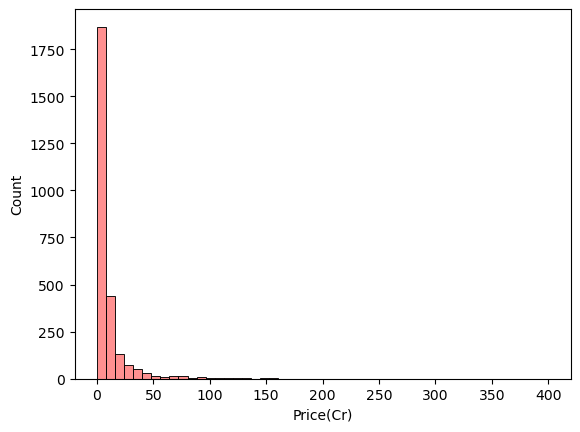

In [37]:
sns.histplot(df['Price(Cr)'],bins=50)

In [38]:
print('Skewness:', df['Price(Cr)'].skew())
print('Kurtosis:', df['Price(Cr)'].kurtosis())

Skewness: 7.40555770838725
Kurtosis: 104.1117554801039


- **Skewness:** 7.4 indicating positive skewness

- **Kurtosis:** 104.11 which is very high meaning that the tails are heavier indicating outliers(which could be seen using boxplot)

In [39]:
df['Price(Cr)'].quantile([0.01,0.1,0.5,0.9,0.99])

0.01     0.490
0.10     1.094
0.50     4.300
0.90    21.300
0.99    86.300
Name: Price(Cr), dtype: float64

<Axes: xlabel='Price(Cr)', ylabel='Proportion'>

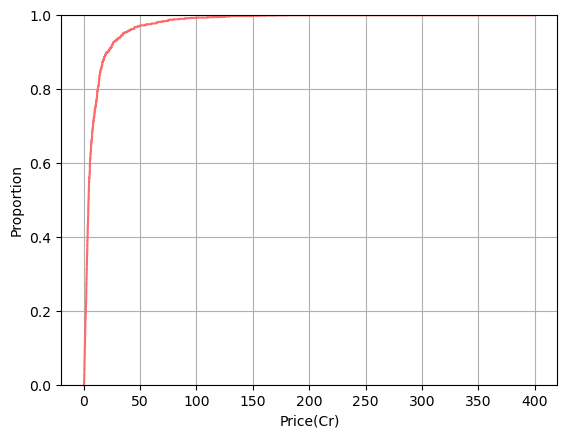

In [40]:
# ECDF Plot 
plt.grid()
sns.ecdfplot(df['Price(Cr)'])

- About 90% of data lies under 50 Cr.

In [41]:
q1,q3 = df['Price(Cr)'].quantile([0.25,0.75])
IQR = q3 - q1

lower_bound = q1 - 1.5*IQR
upper_bound = q3 + 1.5*IQR

print(lower_bound,upper_bound)

-9.8375 22.7025


In [42]:
outliers = df[(df['Price(Cr)']<lower_bound) | (df['Price(Cr)'] > upper_bound)]

In [43]:
outliers['Price(Cr)'].describe()

count    252.000000
mean      49.959405
std       37.385092
min       23.000000
25%       27.725000
50%       37.000000
75%       60.000000
max      400.000000
Name: Price(Cr), dtype: float64

### Outliers Observations
- There are 252 outliers according to IQR
- The range for outliers is 23 Cr till 400 Cr

In [44]:
print('Skewness:', np.log1p(df['Price(Cr)']).skew())
print('Kurtosis:', np.log1p(df['Price(Cr)']).kurtosis())

Skewness: 0.7829283540201816
Kurtosis: 0.48751751590941916


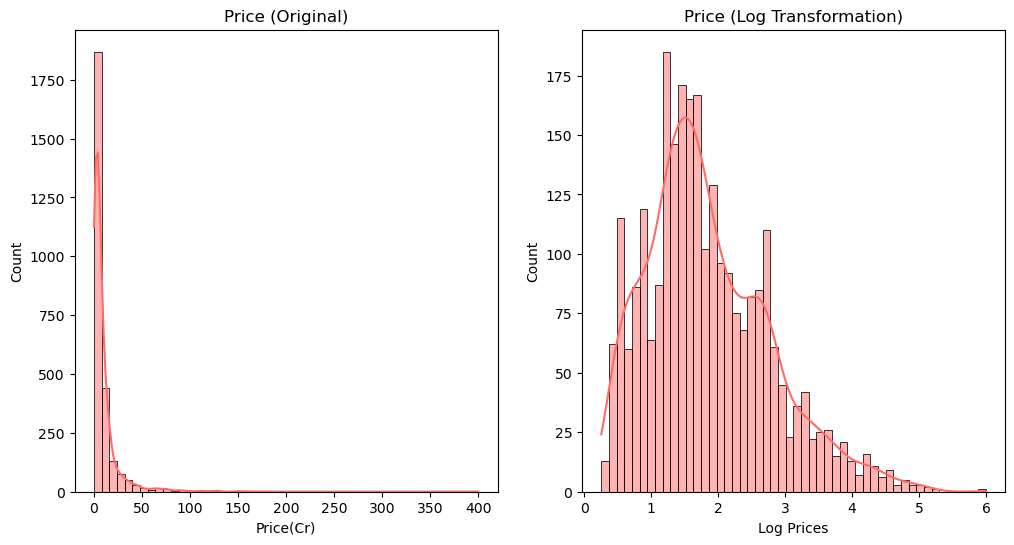

In [45]:
fig, axes = plt.subplots(1,2,figsize=(12,6))

# Before Transformation
sns.histplot(df['Price(Cr)'],kde=True,bins=50,ax=axes[0])
axes[0].set_title('Price (Original)')

sns.histplot(np.log1p(df['Price(Cr)']),kde=True,bins=50,ax=axes[1])
axes[1].set_title('Price (Log Transformation)')
axes[1].set_xlabel('Log Prices');

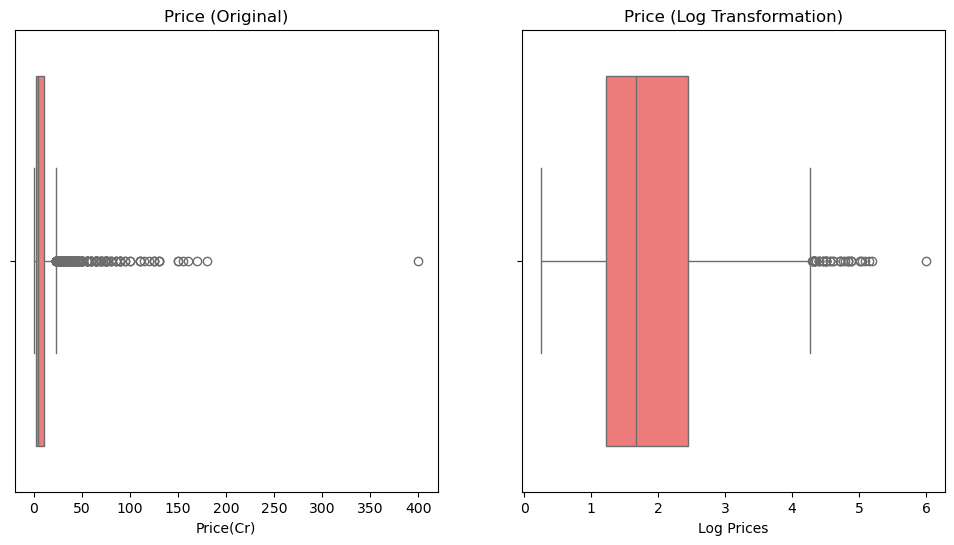

In [46]:
fig, axes = plt.subplots(1,2,figsize=(12,6))

# Before Transformation
sns.boxplot(x=df['Price(Cr)'],ax=axes[0])
axes[0].set_title('Price (Original)')

sns.boxplot(x=np.log1p(df['Price(Cr)']),ax=axes[1])
axes[1].set_title('Price (Log Transformation)')
axes[1].set_xlabel('Log Prices');

**Log Transformation** looks helpful there

## Bath(s)

In [47]:
df['Bath(s)'].isnull().sum()

np.int64(0)

In [48]:
df['Bath(s)'].value_counts()

Bath(s)
6     882
5     388
4     307
2     296
3     260
7     204
1     181
-     154
10      2
9       1
Name: count, dtype: int64

In [51]:
# Need to remove the '-', filling from Bathrooms
df.loc[df['Bath(s)']=='-','Bath(s)'] = df['Bathrooms'].astype(str)

In [55]:
df['Bath(s)'] = df['Bath(s)'].astype(float)

In [56]:
df['Bath(s)'].value_counts()

Bath(s)
6.0     898
5.0     399
4.0     320
2.0     306
3.0     266
7.0     220
1.0     184
8.0      10
9.0       6
10.0      6
12.0      4
16.0      1
Name: count, dtype: int64

<Axes: xlabel='Bath(s)', ylabel='count'>

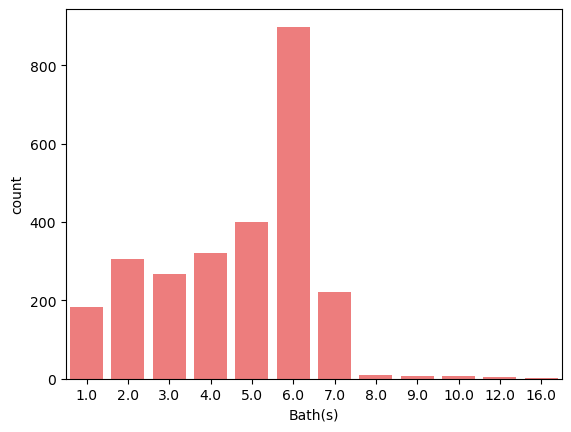

In [57]:
sns.barplot(df['Bath(s)'].value_counts())

## Bedroom(s)

In [58]:
df['Bedroom(s)'].isnull().sum()

np.int64(0)

In [60]:
df['Bedroom(s)'].value_counts()

Bedroom(s)
5     615
4     413
6     380
3     345
2     343
1     156
7     148
-     133
8      66
9      41
10     23
11     12
Name: count, dtype: int64

In [61]:
# Need to fill '-' from Bedrooms
df.loc[df['Bedroom(s)']=='-','Bedroom(s)'] = df['Bedrooms'].astype(str)

In [62]:
df['Bedroom(s)'] = df['Bedroom(s)'].astype(float)

In [67]:
df['Bedroom(s)'].value_counts()

Bedroom(s)
5.0     622
4.0     421
6.0     386
3.0     360
2.0     349
1.0     180
7.0     150
8.0      67
9.0      44
10.0     24
11.0     12
0.0       1
14.0      1
Name: count, dtype: int64

<Axes: xlabel='Bedroom(s)', ylabel='count'>

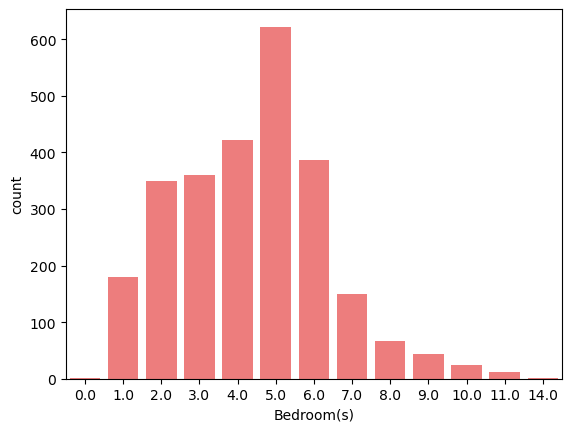

In [66]:
sns.barplot(df['Bedroom(s)'].value_counts())

### Observations from Bath(s) & Bedroom(s)
- In Bath(s), the most frequent no. of Bathrooms is 6.
- In Bedroom(s), the most frequent no. of Bedrooms is 5.
- In both columns, after 7 the number of Bathroom and Bedroom starts to decrease.

## Area(Marla)

In [68]:
df['Area(Marla)'].isnull().sum()

np.int64(0)

In [69]:
df['Area(Marla)'].describe()

count    2675.000000
mean       16.609757
std        76.601586
min         1.000000
25%         5.000000
50%         8.000000
75%        17.800000
max      3000.000000
Name: Area(Marla), dtype: float64

<Axes: xlabel='Area(Marla)', ylabel='Count'>

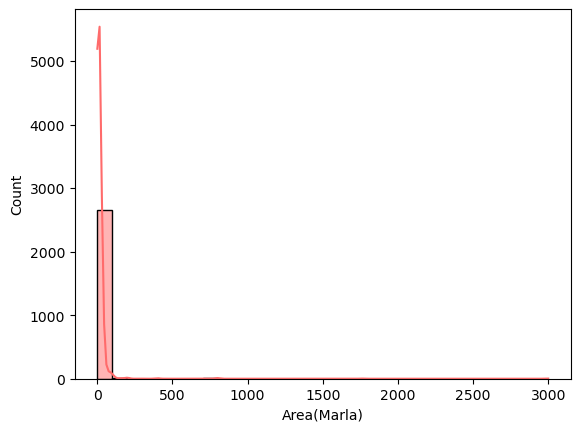

In [70]:
sns.histplot(df['Area(Marla)'],kde=True,bins=30)

<Axes: xlabel='Area(Marla)'>

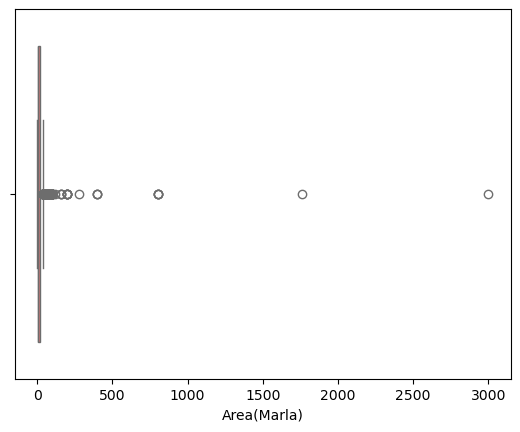

In [71]:
sns.boxplot(x=df['Area(Marla)'])

### Descriptive Statistics
- Mean is 18.76 Marla
- Median is 9.3 Marla
- Mean is larger than Median indicating Outliers
- Standard Deviation being higher also indicates high variability.
- Data is highly right skewed

In [72]:
df['Area(Marla)'].quantile([0.01,0.1,0.5,0.9,0.95,0.99])

0.01      1.8
0.10      4.0
0.50      8.0
0.90     20.0
0.95     40.0
0.99    100.0
Name: Area(Marla), dtype: float64

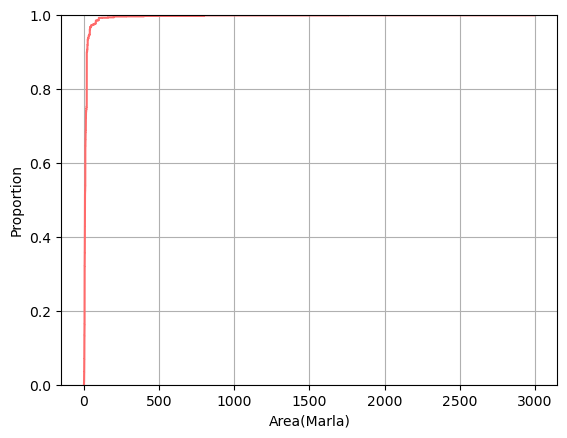

In [73]:
plt.grid()
sns.ecdfplot(df['Area(Marla)']);

### Quantile Observations
- 10% of Data lies below 4 Marla
- 50% of Data lies below 9.3 Marla
- 95% of Data lies below 42 Marla

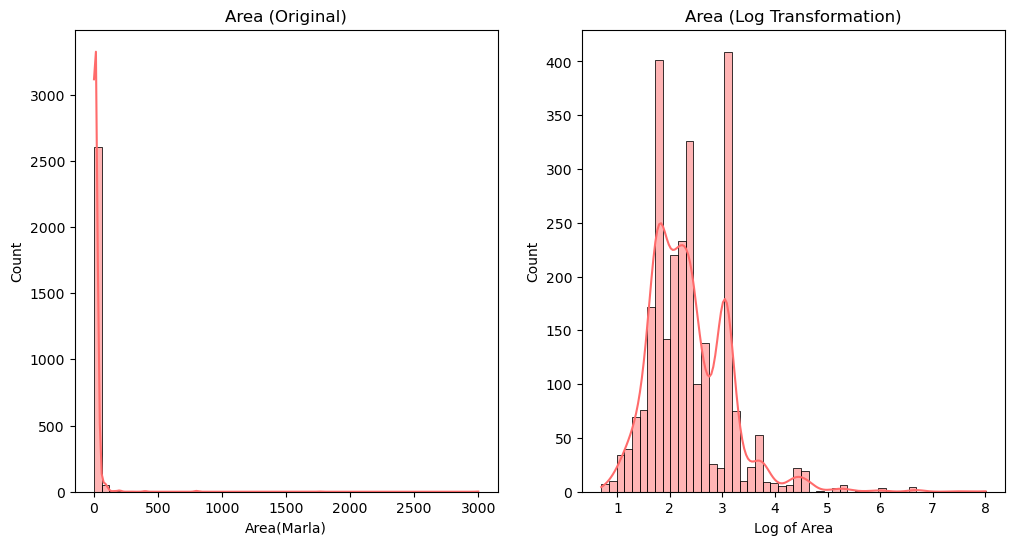

In [74]:
fig, axes = plt.subplots(1,2,figsize=(12,6))

sns.histplot(df['Area(Marla)'],kde=True,bins=50,ax=axes[0])
axes[0].set_title('Area (Original)')

sns.histplot(np.log1p(df['Area(Marla)']),kde=True,bins=50,ax=axes[1])
axes[1].set_title('Area (Log Transformation)')
axes[1].set_xlabel('Log of Area');


## Main Location

In [75]:
df['Main Location'].isnull().sum()

np.int64(0)

In [76]:
df['Main Location'].value_counts()

Main Location
DHA Phase 2                                  251
Bahria Enclave                               196
D-12                                         140
B-17                                         136
G-13                                         123
                                            ... 
H-12                                           1
G-7                                            1
Marwa Town                                     1
FOECHS - Foreign Office Employees Society      1
Phulgran                                       1
Name: count, Length: 111, dtype: int64

In [77]:
df['Main Location'].value_counts(normalize=True).cumsum().head(50)

Main Location
DHA Phase 2              0.093832
Bahria Enclave           0.167103
D-12                     0.219439
B-17                     0.270280
G-13                     0.316262
MPCHS - Multi Gardens    0.358505
Gulberg Greens           0.395514
Top City 1               0.431776
Bani Gala                0.466542
F-8                      0.498318
F-11                     0.523364
DHA Phase 5              0.545794
F-10                     0.567850
DHA Valley               0.589159
Bahria Town              0.608972
F-7                      0.628785
F-6                      0.647850
E-11                     0.666542
I-8                      0.685234
Faisal Town Phase 1      0.703178
G-11                     0.720000
Soan Garden              0.736075
G-9                      0.747664
DHA Phase 1              0.758879
Mumtaz City              0.769346
FECHS                    0.779065
Kashmir Highway          0.788785
Gulberg Residencia       0.798505
G-14                     0.806729


In [82]:
location_counts = df['Main Location'].value_counts()

frequency_bins = {
    'Very high (>200) ':int((location_counts>200).sum()),
    'High (100-200) ' : int(((location_counts>=100) & (location_counts<=200) ).sum()),
    'Moderate (99-40)': int(((location_counts>=40)&(location_counts<=99)).sum()),
    'Low (39-15)': int(((location_counts>=15)&(location_counts<=39)).sum()),
    'Very Low(14-5)': int(((location_counts>=5)&(location_counts<=14)).sum()),
    "Rare (<5)":int((location_counts<5).sum())
}

frequency_bins

{'Very high (>200) ': 1,
 'High (100-200) ': 5,
 'Moderate (99-40)': 16,
 'Low (39-15)': 19,
 'Very Low(14-5)': 24,
 'Rare (<5)': 46}

In [83]:
46+24+19+16+5+1

111

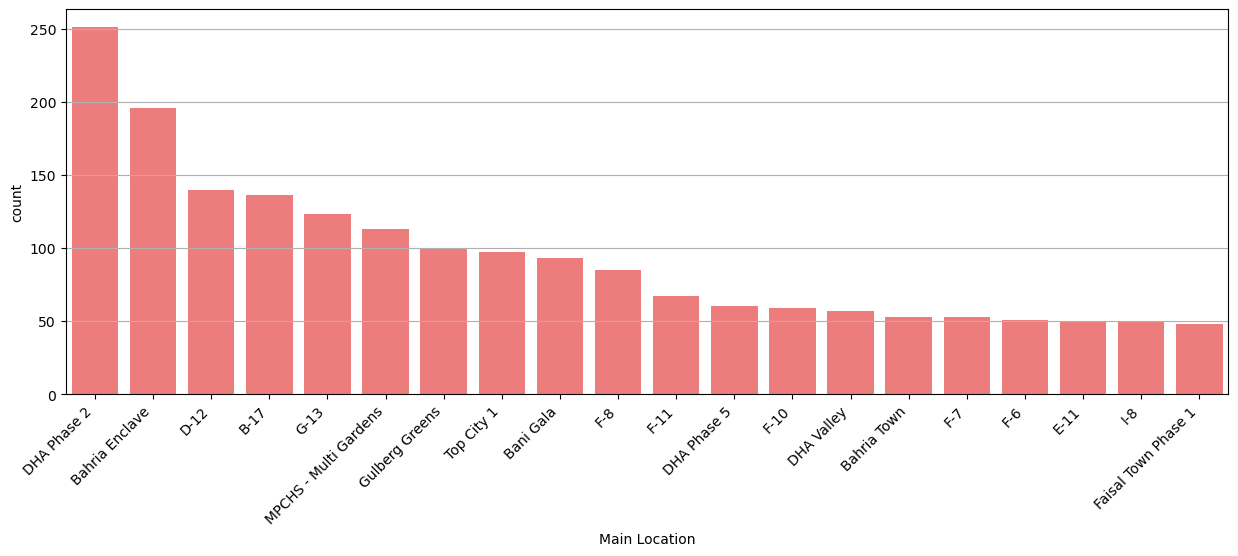

In [88]:
plt.figure(figsize=(15,5))
plt.grid()
sns.barplot(df['Main Location'].str.strip().value_counts().head(20))
plt.xticks(rotation=45,ha='right')
plt.show()

### Observations
- DHA Phase 2 contains 9% of the Data.
- Total 111 different locations
- Top 8 locations contains 50% of data, rest 90 locations contains the rest 50% :
  - Very High(>200): Only 1 location has more than 500 listings
  - High(100 - 200): 5 locations have listings between 100 and 500
  - Moderate(99-40): 16 locations have listings between 40 and 99
  - Low(39-15): 19 locations have listings between 15 and 39
  - Very Low(14-5): 24 locations have less than 15 listings
  - Rare(<5): 46 locations have less than 15 listings

## Building

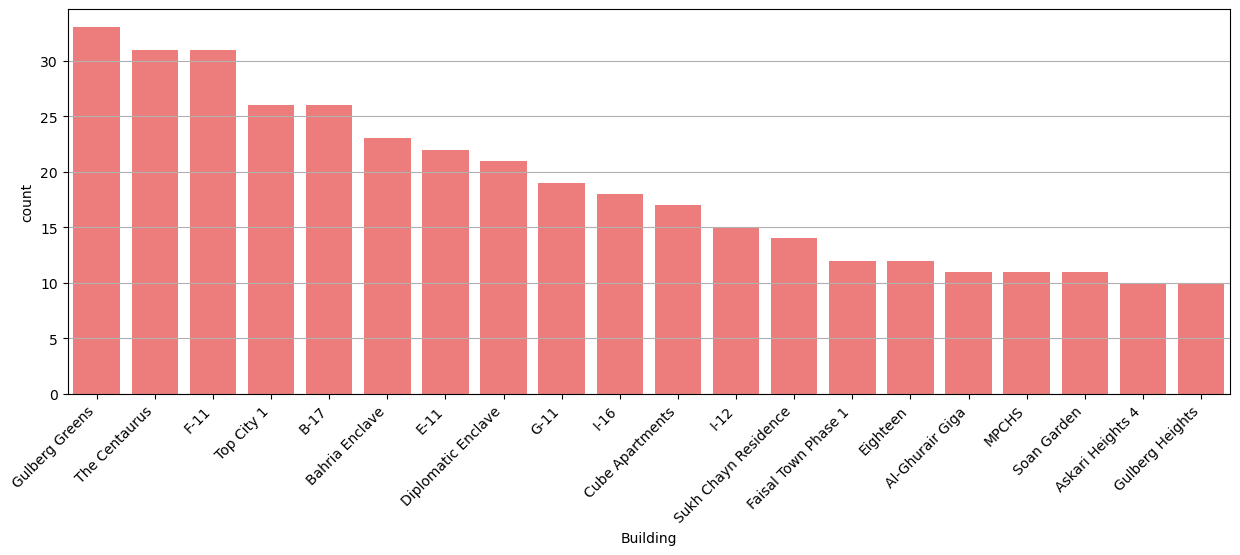

In [89]:
plt.figure(figsize=(15,5))
plt.grid()
sns.barplot(df['Building'].str.strip().value_counts().head(20))
plt.xticks(rotation=45,ha='right')
plt.show()

## IsPrimeLoc, SolarInstalled, WaterBore, CornerHouse

In [90]:
df[['IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse']].isnull().sum()

IsPrimeLoc        0
SolarInstalled    0
WaterBore         0
CornerHouse       0
dtype: int64

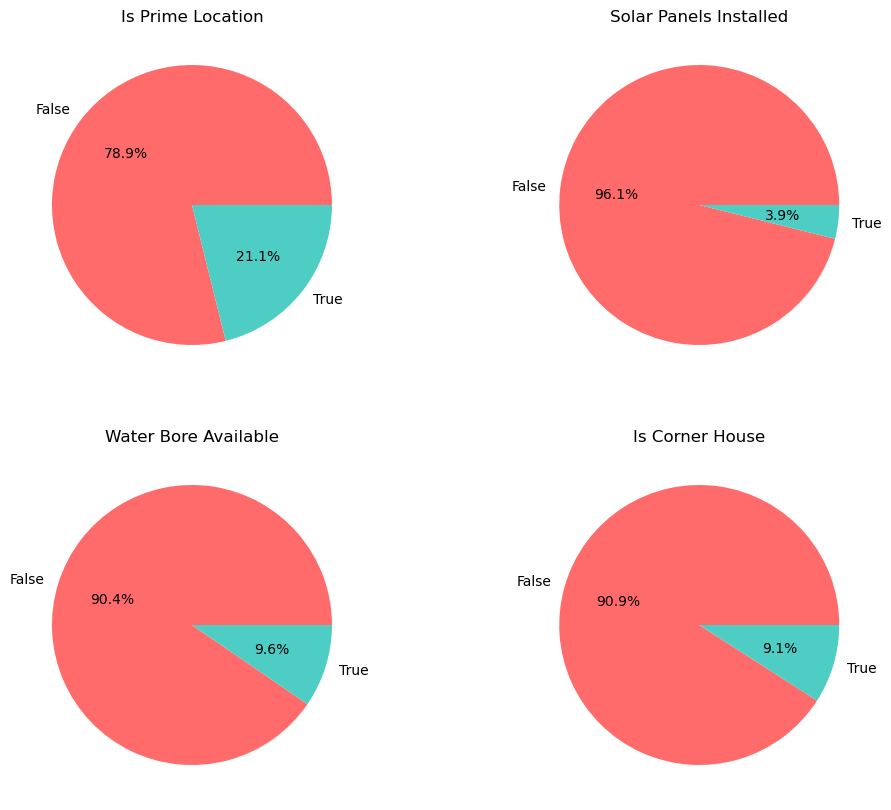

In [91]:
fig, axes = plt.subplots(2,2,figsize=(12,10))

axes[0,0].pie(df['IsPrimeLoc'].value_counts(),autopct='%1.1f%%',labels=df['IsPrimeLoc'].value_counts().index)
axes[0,0].set_title('Is Prime Location')

axes[0,1].pie(df['SolarInstalled'].value_counts(),autopct='%1.1f%%',labels=df['SolarInstalled'].value_counts().index)
axes[0,1].set_title('Solar Panels Installed')

axes[1,0].pie(df['WaterBore'].value_counts(),autopct='%1.1f%%',labels=df['WaterBore'].value_counts().index)
axes[1,0].set_title('Water Bore Available')

axes[1,1].pie(df['CornerHouse'].value_counts(),autopct='%1.1f%%',labels=df['CornerHouse'].value_counts().index)
axes[1,1].set_title('Is Corner House')

plt.show()

In [92]:
df.columns

Index(['Building', 'Main Location', 'Type', 'Price(Cr)', 'Bath(s)',
       'Area(Marla)', 'Bedroom(s)', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Floor in Building', 'Bedrooms',
       'Bathrooms', 'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Swimming Pool', 'Sauna', 'Jacuzzi', 'Security Staff',
       'Maintenance Staff', 'Facilities for Disabled',
       'Laundry or Dry Cleaning Facility', 'Communal/Shared Kitchen'],
      dtype='str')

## Luxury Score

<Axes: xlabel='luxury_type', ylabel='count'>

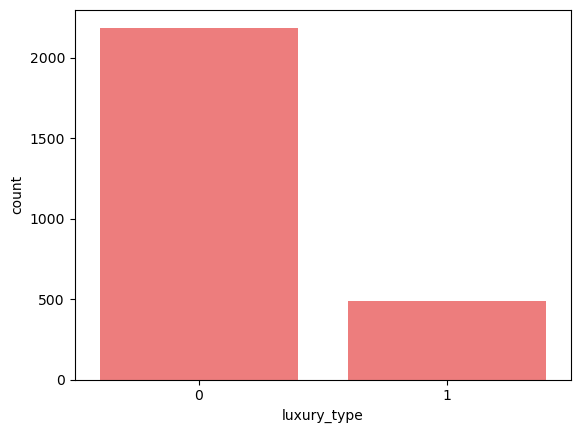

In [93]:
sns.barplot(df['luxury_type'].value_counts())

In [94]:
set(df[df['luxury_type']==0]['Amenities: Main Features'].dropna().sample(10).str.split(', ').sum())

{'Built in year',
 'Built in year: 2016',
 'Built in year: 2020',
 'Built in year: 2021',
 'Built in year: 2024',
 'Built in year: 2025',
 'Built in year: 2027',
 'Central Air Conditioning',
 'Central Heating',
 'Double Glazed Windows',
 'Electricity Backup',
 'Elevators',
 'Floor: 2',
 'Floor: 3',
 'Flooring',
 'Floors',
 'Floors in Building: 14',
 'Floors in Building: 6',
 'Floors: 2',
 'Furnished',
 'Lobby in Building',
 'Other Main Features',
 'Parking Spaces',
 'Parking Spaces: 1',
 'Parking Spaces: 2',
 'Parking Spaces: 8',
 'Service Elevators in Building',
 'Waste Disposal'}

In [95]:
set(df[df['luxury_type']==1]['Amenities: Main Features'].dropna().sample(5).str.split(', ').sum())

{'Built in year: 2017',
 'Built in year: 2019',
 'Built in year: 2024',
 'Electricity Backup',
 'Flooring',
 'Floors: 2',
 'Furnished',
 'Other Main Features',
 'Parking Spaces: 1',
 'Parking Spaces: 2',
 'Parking Spaces: 3',
 'Parking Spaces: 8',
 'Waste Disposal'}

## Built in Year

In [100]:
df['Built in year'].value_counts().sort_index()

Built in year
0.0          1
1.0        174
2.0         16
3.0          7
4.0          3
5.0          3
6.0          1
7.0          2
8.0          3
10.0         2
15.0         1
20.0         1
21.0         1
40.0         1
205.0        1
1898.0       1
1970.0       1
1990.0       8
1995.0       2
1997.0       1
1998.0       6
1999.0       5
2000.0      19
2001.0       3
2002.0       6
2004.0       2
2005.0       8
2006.0       1
2008.0       4
2009.0       8
2010.0      31
2011.0       6
2012.0      15
2013.0       5
2014.0       6
2015.0      42
2016.0      18
2017.0      17
2018.0      44
2019.0      30
2020.0      78
2021.0      54
2022.0      99
2023.0     154
2024.0     322
2025.0     956
2026.0      41
2027.0      16
2028.0       2
2029.0       1
2035.0       1
2050.0       1
2054.0       1
2055.0       1
2250.0       1
20000.0      1
20223.0      3
Name: count, dtype: int64

In [98]:
df[df['Built in year']==0.0]['Description']

2329    On a quest to find something remarkable in Isl...
Name: Description, dtype: str

### Observations
- Very misleading values.
- Many values are not even Years, they represent the number in how many years the house was built.

## Parking Spaces

In [53]:
df['Parking Spaces'].value_counts()

Parking Spaces
1.0       1226
2.0        576
3.0        330
4.0        166
5.0         83
6.0         35
10.0        35
7.0         26
8.0         23
15.0         5
20.0         5
100.0        4
22.0         2
70.0         2
35.0         1
11.0         1
21.0         1
250.0        1
32.0         1
400.0        1
1000.0       1
12.0         1
Name: count, dtype: int64

In [54]:
df[df['Parking Spaces']>10]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Swimming Pool,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
407,Flat,0.6585,1.0,2.1,1.0,H-13,"Studio Apartment for Sale Manal Heights, H-13 ...","Built in year: 2025, Parking Spaces: 22, Lobby...","Bedrooms: 1, Bathrooms: 1, Kitchens: 1","Broadband Internet Access, Satellite or Cable ...",...,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
483,Farm House,30.0000,6.0,100.0,10.0,Gulberg,Gulberg Greens Islamabad B Block 5 Kanal Fully...,"Built in year: 2024, Parking Spaces: 15, Doubl...","Bedrooms: 12, Bathrooms: 16, Servant Quarters:...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
486,House,10.7500,6.0,20.0,6.0,G-13,"House for Sale Size, (50x90)1 Kanal Soled Coun...","Built in year: 1990, Parking Spaces: 20, Doubl...","Drawing Room, Dining Room, Study Room, Prayer ...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
639,House,70.0000,6.0,80.0,9.0,F-8,F-8/4 Luxurious House Available for Sale An ex...,"Built in year: 2019, Parking Spaces: 15, Doubl...","Bedrooms: 9, Bathrooms: 9, Servant Quarters: 3...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
775,House,3.5500,6.0,9.0,6.0,Korang Town,8 Marla 3 Side Open House For Sale In Korang T...,"Built in year: 2024, Parking Spaces: 100, Doub...","Bedrooms: 7, Bathrooms: 7, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN
820,Flat,1.1000,1.0,3.8,1.0,Bani Gala,"Robina's Luxury Residences, Islamabad. Stunnin...","Built in year: 2018, Parking Spaces: 70, Lobby...","Bedrooms: 1, Bathrooms: 1, Drawing Room, Dinin...","Satellite or Cable TV Ready, Business Center o...",...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN
878,Farm House,125.0000,6.0,200.0,10.0,Gulberg,"CORNER. Farm House Gulberg Greens, Islamabad F...","Built in year: 2025, Parking Spaces: 20, Floor...","Bedrooms: 10, Bathrooms: 12, Servant Quarters:...","Broadband Internet Access, Satellite or Cable ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
965,Flat,1.5800,2.0,4.4,2.0,H-13,"2 Bed Apartment for Sale Manal Heights, H-13 I...","Built in year: 2025, Parking Spaces: 22, Doubl...","Bedrooms: 2, Bathrooms: 2, Servant Quarters, D...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN
1050,Farm House,110.0000,5.0,800.0,4.0,Chak Shahzad,40 kanal farm house in chak shahzad Cda transf...,"Built in year: 2002, Parking Spaces: 35, Doubl...","Bedrooms: 4, Bathrooms: 4, Servant Quarters: 4...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
1090,Flat,1.8500,2.0,6.3,2.0,Bani Gala,"Robina's Luxury Residences, Islamabad. Stunnin...","Built in year: 2018, Parking Spaces: 70, Lobby...","Bedrooms: 2, Bathrooms: 2, Drawing Room, Dinin...","Satellite or Cable TV Ready, Business Center o...",...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN


In [55]:
df[df['Parking Spaces']==1000]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Swimming Pool,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
2729,House,7.5,6.0,6.7,7.0,G-10,"Elegant,Modern, Stylish Triple Storey 3050 Hou...","Built in year: 2025, Parking Spaces: 1000, Dou...","Bedrooms: 7, Bathrooms: 9, Drawing Room, Dinin...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN


### Observations
- Contains many outliers
- There is a crazy outlier having value 1000.

## Floor

In [56]:
df.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Description', 'Amenities: Main Features', 'Amenities: Rooms',
       'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Floor in Building', 'Bedrooms',
       'Bathrooms', 'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Community Swimming Pool', 'Community Gym', 'Swimming Pool', 'Sauna',
       'Jacuzzi', 'Security Staff', 'Maintenance Staff',
       'Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen'],
      dtype='str')

In [57]:
import pandas as pd
import re

# Creating a sample 'temp' dataframe based on your edge cases
data = {'description': [
    'Beautiful 2 story house in Gulberg',
    'first floor available for rent',
    '1st Floor with nice view',
    'two point five story building',
    '1 unite for sale immediately',
    'single storey farm house',
    'double story with servant quarter',
    'random text with no storey info'
]}
temp = pd.DataFrame(data)

# 1. Define the Regex Pattern
# (?i) makes it case-insensitive.
# It looks for digits, words (one, two), ordinals (1st, first), or multiples (single, double)
# It also includes an optional check for decimals like " point five" or ".5"
# Then it looks for the keywords: storey, story, unit, unite, floor (with optional 's')
regex_pattern = r'(?i)\b((?:1|2|3|4|5|1st|2nd|3rd|one|two|three|first|second|third|single|double|triple)(?:\s+point\s+five|\.5)?)\s*-?\s*(?:storey|story|stories|unit|unite|floor)s?\b'

# 2. Extract the match into a temporary column
# We use .str.lower() and .str.strip() to normalize the text for easier mapping
temp['raw_extracted'] = temp['description'].str.extract(regex_pattern)[0].str.lower().str.strip()

# 3. Create a dictionary to map the messy text to clean floats/integers
storey_mapping = {
    '1': 1.0, '1st': 1.0, 'one': 1.0, 'first': 1.0, 'single': 1.0,
    '2': 2.0, '2nd': 2.0, 'two': 2.0, 'second': 2.0, 'double': 2.0,
    '3': 3.0, '3rd': 3.0, 'three': 3.0, 'third': 3.0, 'triple': 3.0,
    '2.5': 2.5, 'two point five': 2.5, '2.5': 2.5
}

# 4. Map the values to a final clean column and drop the temporary one
temp['storey_unit_clean'] = temp['raw_extracted'].map(storey_mapping)
temp = temp.drop(columns=['raw_extracted'])

(temp)

,description,storey_unit_clean
0,Beautiful 2 story house in Gulberg,2.0
1,first floor available for rent,1.0
2,1st Floor with nice view,1.0
3,two point five story building,2.5
4,1 unite for sale immediately,1.0
5,single storey farm house,1.0
6,double story with servant quarter,2.0
7,random text with no storey info,NaN


In [58]:
df['raw_extracted'] = df['Description'].str.extract(regex_pattern)[0].str.lower().str.strip()
df['Storey Unit'] = df['raw_extracted'].map(storey_mapping)
df.drop(columns=['raw_extracted'],inplace=True)

In [59]:
df['Storey Unit'].fillna(0).value_counts()

Storey Unit
0.0    2060
2.0     478
1.0     191
3.0     129
2.5       8
Name: count, dtype: int64

In [60]:
df['Storey Unit'].dropna().index

Index([   1,    2,    5,    7,   11,   14,   15,   16,   18,   20,
       ...
       2819, 2821, 2833, 2836, 2837, 2839, 2848, 2859, 2860, 2863],
      dtype='int64', length=806)

In [61]:
df[df['Floor']>2].index

Index([  18,   20,   26,   37,   38,   41,   46,   66,   69,   74,
       ...
       2769, 2771, 2775, 2791, 2794, 2805, 2834, 2838, 2856, 2865],
      dtype='int64', length=462)

In [62]:
df.loc[20].Floor

np.float64(3.0)

In [63]:
df['Storey Unit'].loc[18]

np.float64(3.0)

In [64]:
df[df['Floor']==0].index

RangeIndex(start=0, stop=0, step=1)

In [65]:
df.loc[df[df['Floor']==0].index,'Floor'] =  df.loc[df[df['Floor']==0].index,'Storey Unit'].fillna(0)

In [66]:
df.loc[df[df['Floor']>2].index,'Storey Unit'].value_counts()

Storey Unit
3.0    68
2.0    29
1.0    21
2.5     2
Name: count, dtype: int64

In [67]:
df['Floor'].value_counts()

Floor
2.0     1193
1.0      401
3.0      266
4.0       48
5.0       43
6.0       20
8.0       16
7.0       14
9.0       11
10.0       8
12.0       8
11.0       4
17.0       3
18.0       3
13.0       3
24.0       2
14.0       2
40.0       2
1.5        2
20.0       2
37.0       1
15.0       1
38.0       1
23.0       1
32.0       1
2.5        1
16.0       1
Name: count, dtype: int64

In [68]:
df[df['Floor']==0]['Description']

Series([], Name: Description, dtype: str)

In [69]:
df.loc[36]['Description']

'Al Ahram property offer you 5 kanal fully furnished foam house for sale in gulberg green islamabad More options also available in gulberg green or Dha phase 2 islamabad If you want purchase this property so contact with us we give you best service inshaAllah Regards Rizwan ch'

In [70]:
df['Amenities: Rooms'].loc[6]

'Bedrooms: 5, Bathrooms: 5, Servant Quarters: 1, Drawing Room, Dining Room, Kitchens: 2, Study Room, Prayer Room, Powder Room, Gym, Steam Room, Lounge or Sitting Room, Laundry Room'

In [71]:
df[df['Floor']==3].head()['Description']

18    House For Sale 400Sq. yd in F/11 6Bedrooms Tri...
20    8 Marla Beautiful Triple Story House for Sale ...
26    DHA phase 1 Sector F Defense Villa For Sale 3 ...
37    Corner House For Sale 50/90 Triple Story Prime...
38    Beautiful House For Sale 5 Bedrooms Big Loan 4...
Name: Description, dtype: str

In [72]:
df.loc[38]['Description']

'Beautiful House For Sale 5 Bedrooms Big Loan 450 Sq. Yd. Triple Story All Facilities are available Further Details Contact us ; Muhammad Atif View Contact Detail'

In [73]:
df[df['Floor']>4]['Type'].value_counts()

Type
Flat     143
House      4
Name: count, dtype: int64

In [74]:
df[(df['Floor']>4)&(df['Type']=='House')]['Floor']

909     40.0
1055    38.0
1890    13.0
2631    11.0
Name: Floor, dtype: float64

In [75]:
df.loc[1055]['Description']

'F-11/4 corner house for sale size 50x90 6 bed 2 kitchen with basement'

In [76]:
df.loc[1055]

Type                                                                                 House
Price(Cr)                                                                             18.5
Bath(s)                                                                                6.0
Area(Marla)                                                                           20.0
Bedroom(s)                                                                             8.0
Location                                                                              F-11
Description                              F-11/4 corner house for sale size 50x90 6 bed ...
Amenities: Main Features                 Built in year: 2003, Parking Spaces: 4, Double...
Amenities: Rooms                         Bedrooms: 8, Bathrooms: 9, Drawing Room, Dinin...
Amenities: Business and Communication    Broadband Internet Access, Satellite or Cable ...
Amenities: Community Features            Community Lawn or Garden, Community Swimming P...

In [77]:
# 909 is a 'Flat' but its rest of features are given as 'House' --> removing it
df.drop(index=909,inplace=True)

In [78]:
# Changing the values for 'Floor'>4 for Houses
df.loc[1890,'Floor'] = 2
df.loc[2631,'Floor'] = 2
df.loc[1055,'Floor'] = 2

## Lobby in Building, Service in Elevators, Elevators

In [79]:
df['Lobby in Building'].value_counts()

Lobby in Building
1.0    534
Name: count, dtype: int64

In [80]:
df['Service Elevators in Building'].value_counts()

Service Elevators in Building
1.0    478
Name: count, dtype: int64

In [81]:
df['Elevators'].value_counts()

Elevators
1.0     212
2.0     103
4.0      83
3.0      44
6.0      22
5.0      20
8.0      13
7.0       4
10.0      4
16.0      2
15.0      2
9.0       1
14.0      1
12.0      1
11.0      1
Name: count, dtype: int64

In [82]:
df[df['Elevators']>8]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
612,Flat,1.50,3.0,7.5,3.0,Bahria Town,"The Galleria Mall, Civic Zone, Sector H Brand ...","Built in year: 2023, Parking Spaces: 1, Lobby ...","Bedrooms: 3, Bathrooms: 3, Dining Room, Kitche...","Broadband Internet Access, Satellite or Cable ...",...,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN
1039,Flat,13.50,4.0,11.8,3.0,Karakoram Diplomatic Enclave,Karakoram 3 bed rooms apartment with covered a...,"Built in year: 2018, Parking Spaces: 01, Lobby...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 0...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
1553,Flat,7.99,2.0,13.8,2.0,F-10,*The Garden Residence Luxury Apartments for Sa...,"Built in year: 2025, Parking Spaces: 3, Lobby ...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
1596,Flat,0.50,1.0,2.9,NaN,DHA Defence,Studio Apartment For Sale on Installments. In ...,"Built in year: 2028, Parking Spaces: 1, Lobby ...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618,Flat,1.60,2.0,5.6,2.0,Bahria Town,Discover modern living in the heart of Bahria ...,"Built in year: 2023, Parking Spaces: 1, Lobby ...","Bedrooms: 2, Bathrooms: 2, Servant Quarters: 1...","Broadband Internet Access, Business Center or ...",...,1.0,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN
1667,Flat,2.10,3.0,8.3,2.0,Gulberg,Gulberg areena two bed furnished r non furnish...,"Built in year: 2024, Parking Spaces: 4, Lobby ...","Bedrooms: 4, Bathrooms: 2, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
1754,Flat,1.30,1.0,4.2,1.0,Bahria Town,Beautifully designed 1 Bedroom Apartment avail...,"Built in year: 2022, Parking Spaces: 1, Lobby ...","Bedrooms: 1, Bathrooms: 1, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN
1968,Flat,5.49,3.0,7.8,3.0,F-10,Three Bedrooms Corner Apartment With Long Terr...,"Built in year: 2012, Parking Spaces: 1, Lobby ...","Bedrooms: 3, Bathrooms: 3, Drawing Room, Dinin...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
2040,Flat,3.85,2.0,6.4,2.0,G-11,Fully Furnished 2bed With Attached Washrooms L...,"Built in year: 2025, Parking Spaces: 1, Lobby ...","Bedrooms: 2, Bathrooms: 2, Drawing Room, Dinin...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,1.0,NaN
2220,Flat,1.35,3.0,7.5,3.0,Bahria Town,Brand New 3 bedrooms Apartment park facing ava...,"Built in year: 2025, Parking Spaces: 1, Lobby ...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,NaN,1.0,1.0,NaN,NaN,NaN


## Servant Quarters

In [83]:
df['Servant Quarters'].isnull().sum() / df.shape[0]

np.float64(0.25165794066317626)

In [84]:
df['Servant Quarters'].value_counts().cumsum() / df['Servant Quarters'].dropna().shape[0]

Servant Quarters
1.0     0.616604
2.0     0.847015
0.0     0.970149
3.0     0.987407
4.0     0.993937
8.0     0.995802
6.0     0.996735
12.0    0.997668
5.0     0.998601
11.0    0.999067
22.0    0.999534
7.0     1.000000
Name: count, dtype: float64

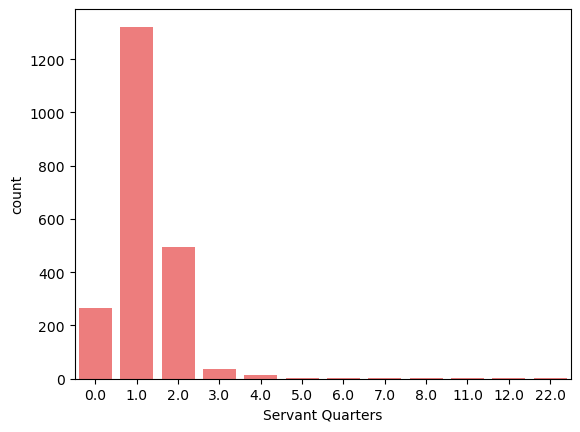

In [85]:
sns.barplot(df['Servant Quarters'].value_counts());

In [86]:
df[df['Servant Quarters']>4]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
78,Flat,0.60,2.0,3.9,2.0,I-12,PHA Flat I-12 D-type available for sale Pakist...,"Built in year: 2, Parking Spaces: 2, Lobby in ...","Bedrooms: 2, Bathrooms: 2, Servant Quarters: 1...",Other Business and Communication Facilities,...,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN
90,House,11.80,6.0,20.0,6.0,DHA Defence,1 Kanal House for Sale in DHA Defence Phase 2 ...,"Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 8...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
262,House,8.00,7.0,20.0,11.0,Top City 1,500 Square Yards property is best for long ter...,"Built in year: 2010, Parking Spaces: 7, Double...","Bedrooms: 8, Bathrooms: 10, Servant Quarters: ...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
305,House,4.50,4.0,5.6,4.0,G-8,25*50 Cda Transfer Back Open Good Location Hou...,"Built in year: 2025, Parking Spaces: 1, Double...","Bedrooms: 4, Bathrooms: 4, Servant Quarters: 6...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
503,House,15.00,6.0,20.0,5.0,DHA Defence,"1 Kanal Modern House for Sale DHA Phase 2, Isl...","Built in year: 2025, Parking Spaces: 1, Double...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 8...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
504,House,11.80,7.0,20.0,6.0,DHA Defence,Property Features: 1 Kanal (500 Sq. Yards) Dou...,"Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 8...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,2.0
506,House,11.65,7.0,20.0,6.0,DHA Defence,"Location: DHA Defence Phase 2, Islamabad Size:...","Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 6, Bathrooms: 3, Servant Quarters: 8...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
1198,House,2.05,4.0,5.0,4.0,B-17,Fasial Margalla City House. For sale 5 marla d...,"Built in year: 2025, Parking Spaces: 1, Double...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN
1571,House,3.50,6.0,8.0,5.0,Faisal Town - F-18,8 MARLA LUXURY DOUBLE STORY HOUSE FOR SALE IN ...,"Built in year: 1, Parking Spaces: 2, Double Gl...","Bedrooms: 5, Bathrooms: 5, Servant Quarters: 6...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,2.0
2240,House,6.40,6.0,7.0,5.0,G-13,30x60 Beautiful House For Sale In G-13 5 Bedro...,"Built in year: 2023, Parking Spaces: 1, Double...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 7...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN


In [87]:
df[df['Servant Quarters']==22]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
262,House,8.0,7.0,20.0,11.0,Top City 1,500 Square Yards property is best for long ter...,"Built in year: 2010, Parking Spaces: 7, Double...","Bedrooms: 8, Bathrooms: 10, Servant Quarters: ...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN


### Observations 
- About 25% is missing.
- 97% of values are contained in 1,0,2
- Values above 4 can be considered outliers since they account to very less proportion of data and they are misleading.

## Kitchens

In [88]:
df['Kitchens'].isnull().sum()

np.int64(353)

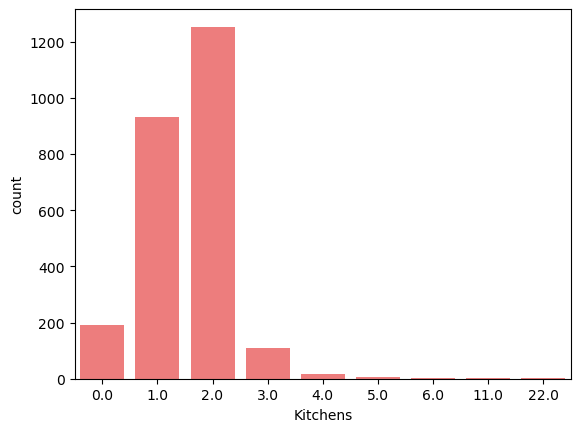

In [89]:
sns.barplot(df['Kitchens'].value_counts());

- Kitchen no. exceeding 4 can be potential outliers

In [90]:
df['Kitchens'].value_counts()

Kitchens
2.0     1253
1.0      933
0.0      192
3.0      110
4.0       16
5.0        5
22.0       1
11.0       1
6.0        1
Name: count, dtype: int64

In [91]:
df[df['Kitchens']==4][['Description','Area(Marla)','Kitchens','Floor']]

,Description,Area(Marla),Kitchens,Floor
456,Brand-New 1 Kanal Ultra-Modern House for Sale ...,20.0,4.0,2.0
545,G-13 Brand New 500 Yds Architect Design Owner ...,20.0,4.0,3.0
566,* 10 Marla Brand New Proper Corner Double Stor...,10.0,4.0,1.0
977,F7/3 Luxury Spacious Brand New House Available...,24.0,4.0,3.0
1005,G-13/4 70 FT ROAD Brand New 500 Yds Architect ...,20.0,4.0,2.0
1668,A Block Gulberg Greens Islamabad Furnished Non...,100.0,4.0,3.0
1956,Furnished farm house available for sale A bloc...,100.0,4.0,3.0
1988,A Block Gulberg Greens Islamabad Furnished Hou...,20.0,4.0,3.0
2063,Cda sector G-7/4(90*80)=800-Sq yards 8-bed roo...,32.0,4.0,1.0
2085,One Of A Kind Peace Of Land For Sale In Dha Ph...,20.0,4.0,2.0


In [92]:
df['Description'].loc[566]

'* 10 Marla Brand New Proper Corner Double Story House Available for Sale in Topcity-1 Islamabad! * **Solid Construction** **Location**: Topcity-1, Islamabad Near to New Islamabad International Airport, **Size**: *10 Marla Proper Corner House* **Detail**: - **Bedrooms**: 5 + 1 Servant Room with Bath - **Bathrooms**: 7 - **Kitchens**: 2 - **Drawing Room**: 2 - **TV Lounch**: 2 - **Tiles Flooring** - **2 Big Car parking Inside the House** **Amenities**: - Electricity,Water - Nearby Mosque - Nearby Market - Nearby School - Nearby Metro Station - Nearby Park **Completion Done. ** **Demand* 550 Lacs **Contact Us Now to Schedule a Visit!** Nouman Khan Call/WhatsApp:'

In [93]:
df.loc[2747,"Kitchens"] = 2
df.loc[2590,"Kitchens"] = 2
df.loc[2085,"Kitchens"] = 2
df.loc[2063,"Kitchens"] = 1
df.loc[1005,"Kitchens"] = 1

In [94]:
df[df['Kitchens']>4][['Kitchens','Floor','Storey Unit']]

,Kitchens,Floor,Storey Unit
97,5.0,1.0,NaN
128,5.0,2.0,2.0
591,5.0,3.0,2.0
686,5.0,2.0,NaN
1206,22.0,2.0,NaN
1954,11.0,NaN,NaN
2794,5.0,3.0,3.0
2865,6.0,3.0,NaN


In [95]:
df['Description'].loc[2865]

'Kanal+ Big and Elegant House is available for Sale in G11 Islamabad Size 60x90 14 Bedrooms 16 Washrooms 6 Drwaing Dinings 6 TVLs 6 Kitchens 3 Gates 4 Gas Meters 4 Electric Meters Ample parking space Corner with extra land and basement Wide streets Near by Masjid and Market CDA Transfer P. S. : Pictures are real'

In [96]:
df.loc[2865]

Type                                                                                 House
Price(Cr)                                                                             16.0
Bath(s)                                                                               16.0
Area(Marla)                                                                           22.0
Bedroom(s)                                                                            14.0
Location                                                                              G-11
Description                              Kanal+ Big and Elegant House is available for ...
Amenities: Main Features                 Built in year: 2025, Parking Spaces: 6, Floori...
Amenities: Rooms                         Bedrooms: 14, Bathrooms: 16, Servant Quarters:...
Amenities: Business and Communication    Broadband Internet Access, Satellite or Cable ...
Amenities: Community Features             Community Lawn or Garden, Kids Play Area, Mosque

In [97]:
df.loc[128,'Kitchens'] = 2
df.loc[591,'Kitchens'] = 2
df.loc[686,'Kitchens'] = 2
df.loc[1206,'Kitchens'] = 2
df.loc[1954,'Kitchens'] = 2

### Observations 
- There were some errors in the values. (Fixed it manually)

## Store Rooms

<Axes: xlabel='Store Rooms', ylabel='count'>

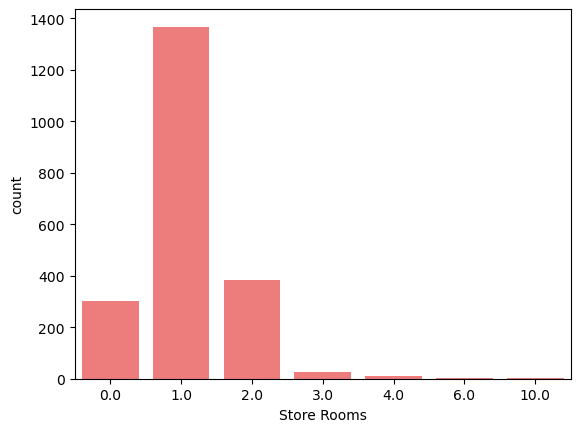

In [98]:
sns.barplot(df['Store Rooms'].value_counts())

In [99]:
df[df['Store Rooms']==0]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen,Storey Unit
12,Farm House,85.00,7.0,200.0,8.0,Gulberg,Al Ahram Property Offer You A Brand New 10 Kan...,"Built in year, Parking Spaces, Double Glazed W...","Bedrooms: 8, Bathrooms: 8, Servant Quarters: 4...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
14,House,2.25,3.0,8.0,2.0,Jinnah Garden,Brand new Modern designed single storey house ...,"Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 2, Bathrooms: 3, Servant Quarters, D...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0
16,Flat,1.85,2.0,6.1,2.0,Gulberg,Gulberg Heights 2bed Room 1370 Sqft 3th Floor ...,"Built in year: 2022, Parking Spaces, Lobby in ...","Bedrooms: 2, Bathrooms: 2, Servant Quarters, D...","Broadband Internet Access, Satellite or Cable ...",...,1.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,2.0
20,House,9.75,7.0,8.0,7.0,D-12,8 Marla Beautiful Triple Story House for Sale ...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 7, Bathrooms: 7, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,3.0
32,House,26.00,7.0,40.0,7.0,DHA Defence,Al Ahram property offer you fully furnished tr...,"Built in year, Parking Spaces, Double Glazed W...","Bedrooms: 7, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2776,House,4.30,6.0,10.0,5.0,Top City 1,Brand New 10 Marla House For Sale We Are Pleas...,"Built in year: 2024, Parking Spaces, Double Gl...","Bedrooms, Bathrooms, Servant Quarters, Drawing...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
2787,House,3.50,7.0,8.0,6.0,Faisal Town - F-18,Description Direct Meeting With Owner 08 Marla...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN,2.0
2812,House,4.50,5.0,5.0,4.0,DHA Defence,If you are looking to buy a property in Islama...,"Built in year: 2024, Parking Spaces, Double Gl...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
2818,House,65.00,6.0,160.0,7.0,Eighteen,The Villas Of Eighteen Are Designed For Those ...,"Built in year: 2024, Parking Spaces: 8, Double...","Bathrooms: 7, Servant Quarters, Drawing Room, ...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN


# Saving

In [100]:
df.to_csv('zameen_eda_cleaned.csv')